**CESAR - School**<br>
**Especialização: Engenharia e Análise de Dados** - **Turma:** 2025.2<br>
**RNA e Deep Learning**<br>
**Aula 3 - Exercício 2**

**Docente:** Vitor Casadei<br>
**Discente:** Caio Augustus Lima de Abreu Monteiro<br>


# Regressão Softmax com dados do MNIST

## Objetivo

O objetivo deste notebook é ilustrar o uso de praticamente a mesma rede desenvolvida para a classificação das flores Íris, porém agora com o problema de classificação de dígitos manuscritos utilizando o dataset MNIST.
As principais diferenças são:
- tipo do dado, agora imagem com muito atributos: 28 x 28 pixels
- número de amostras, muito maior, 60 mil
Neste exercício será possível a interpretação do significado dos parâmetros treinados

## Importação das bibliotecas

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
from torch.autograd import Variable

import torchvision

## Carregamento dos dados do MNIST

In [2]:
! git clone https://github.com/vcasadei/MNIST.git

fatal: destination path 'MNIST' already exists and is not an empty directory.


In [3]:
!ls MNIST

processed  raw


In [4]:
dataset_dir = 'MNIST/'

x_train, y_train = torch.load(dataset_dir + 'processed/training.pt')

print("Amostras de treinamento:", x_train.size(0))

print("\nDimensões dos dados das imagens:   ", x_train.size())
print("Valores mínimo e máximo dos pixels:", torch.min(x_train), torch.max(x_train))
print("Tipo dos dados das imagens:        ", type(x_train))
print("Tipo das classes das imagens:      ", type(y_train))

Amostras de treinamento: 60000

Dimensões dos dados das imagens:    torch.Size([60000, 28, 28])
Valores mínimo e máximo dos pixels: tensor(0, dtype=torch.uint8) tensor(255, dtype=torch.uint8)
Tipo dos dados das imagens:         <class 'torch.Tensor'>
Tipo das classes das imagens:       <class 'torch.Tensor'>


### Carregamento, normalização e seleção dos dados do MNIST

Neste exemplo utilizaremos apenas 1000 amostras de treinamento.

In [5]:
x_train = x_train.float()

x_train = x_train / 255.

if True:
    n_samples_train = 1000

    x_train = x_train[:n_samples_train]
    y_train = y_train[:n_samples_train]

print("Amostras de treinamento:", x_train.size(0))

print("\nDimensões dos dados das imagens:   ", x_train.size())
print("Valores mínimo e máximo dos pixels:", torch.min(x_train), torch.max(x_train))
print("Tipo dos dados das imagens:        ", type(x_train))
print("Tipo das classes das imagens:      ", type(y_train))

Amostras de treinamento: 1000

Dimensões dos dados das imagens:    torch.Size([1000, 28, 28])
Valores mínimo e máximo dos pixels: 

tensor(0.) tensor(1.)
Tipo dos dados das imagens:         <class 'torch.Tensor'>
Tipo das classes das imagens:       <class 'torch.Tensor'>


### Carregamento e normalização dos dados de validação

In [6]:
x_val, y_val = torch.load(dataset_dir + 'processed/test.pt')

x_val = x_val.float()
x_val = x_val / 255.

# Limit validation samples for consistency with training set, if needed
# If you want to use the full test set for validation, comment this block
if True:
    n_samples_val = 200 # Using a smaller validation set for demonstration

    x_val = x_val[:n_samples_val]
    y_val = y_val[:n_samples_val]

print("Amostras de validação:", x_val.size(0))

print("\nDimensões dos dados das imagens de validação:   ", x_val.size())
print("Valores mínimo e máximo dos pixels de validação:", torch.min(x_val), torch.max(x_val))
print("Tipo dos dados das imagens de validação:        ", type(x_val))
print("Tipo das classes das imagens de validação:      ", type(y_val))

Amostras de validação: 200

Dimensões dos dados das imagens de validação:    torch.Size([200, 28, 28])
Valores mínimo e máximo dos pixels de validação: tensor(0.) tensor(1.)
Tipo dos dados das imagens de validação:         <class 'torch.Tensor'>
Tipo das classes das imagens de validação:       <class 'torch.Tensor'>


### Visualizando os dados

(np.float64(-0.5), np.float64(232.5), np.float64(87.5), np.float64(-0.5))

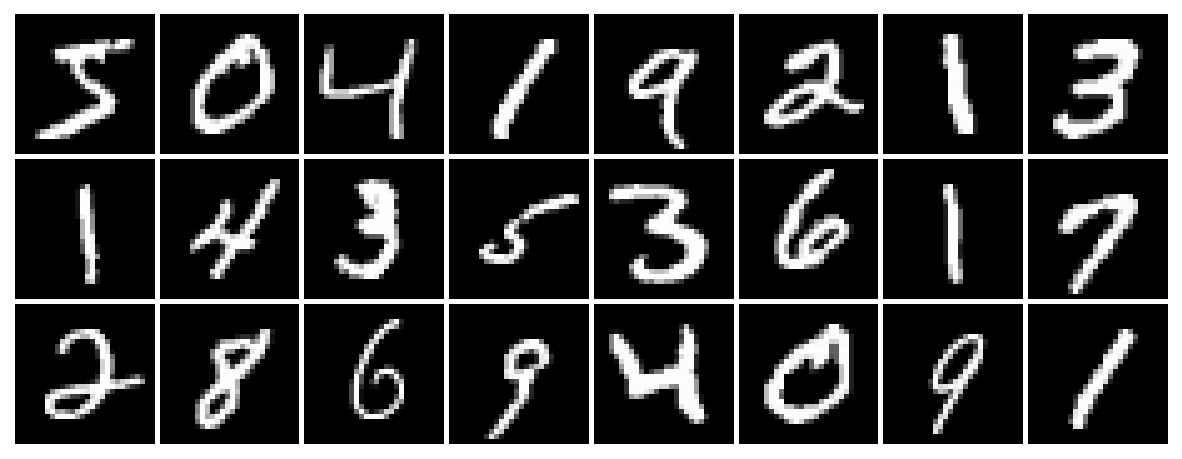

In [7]:
n_samples = 24

# cria um grid com as imagens
grid = torchvision.utils.make_grid(x_train[:n_samples].unsqueeze(dim=1), pad_value=1.0, padding=1)

plt.figure(figsize=(15, 10))
plt.imshow(grid.numpy().transpose(1, 2, 0))
plt.axis('off')

### Visualizando uma imagem com o matplotlib

class: tensor(5)


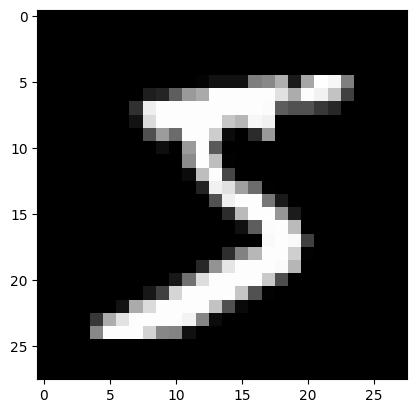

In [8]:
image  = x_train[0]
target = y_train[0]

plt.imshow(image.numpy(), cmap='gray')
print('class:', target)

## Modelo

In [9]:
model = torch.nn.Linear(28*28, 10) # 28*28 atributos de entrada e 10 neurônios na sáida

### Testando um predict com poucas amostras

In [10]:
xin = x_train[:5].view(-1,28*28)
score = model(Variable(xin))
score

tensor([[ 0.0495, -0.0299, -0.0280, -0.2192,  0.1285, -0.1832,  0.0829,  0.2002,
          0.0699, -0.0914],
        [-0.2292, -0.0156,  0.1059, -0.3793, -0.0056, -0.4652, -0.1204,  0.2397,
         -0.2001, -0.3461],
        [-0.0320,  0.2066,  0.2710,  0.1133,  0.1037, -0.4190,  0.2248,  0.0424,
          0.0916, -0.1450],
        [-0.0691,  0.0253,  0.2857, -0.2956, -0.1124,  0.0060,  0.0787,  0.1728,
         -0.0567, -0.0907],
        [ 0.1455,  0.1075,  0.0650, -0.3717,  0.0785, -0.7338, -0.1466,  0.1768,
         -0.1978, -0.0565]], grad_fn=<AddmmBackward0>)

## Treinamento

### Inicialização dos parâmetros

In [11]:
epochs = 100
learningRate = 0.5

# Utilizaremos CrossEntropyLoss como função de perda
criterion = torch.nn.CrossEntropyLoss()

# Gradiente descendente
optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)

### Laço de treinamento dos pesos

**Atividades 1 e 2 — implementação no laço de treinamento**

O laço de treinamento abaixo incorpora as duas atividades solicitadas:

- **Atividade 1**: ao final de cada época, são impressos o número da época, a perda (*loss*) e a acurácia, calculada pela proporção de predições corretas em relação aos rótulos verdadeiros.

- **Atividade 2**: ao final de cada época, registra-se e visualiza-se o gradiente associado à classe do dígito 4. Um aspecto técnico essencial é o momento da coleta: o gradiente da camada linear (`model.weight.grad`) só está disponível **após a chamada de `loss.backward()`**, que efetua a retropropagação, e **antes de `optimizer.zero_grad()`** da iteração seguinte, que o zera. A matriz de gradientes tem o mesmo formato da matriz de pesos — `(10, 784)`, uma linha por classe —, de modo que a linha de índice 4 contém os 784 gradientes referentes ao dígito 4. Esses valores são remodelados para o formato `28 × 28`, permitindo a interpretação espacial do gradiente como uma imagem, na qual o mapa de cores `seismic` distingue contribuições positivas (vermelho) e negativas (azul).

Cabe observar a distinção conceitual entre **pesos** e **gradientes**: os pesos (`model.weight`) representam os parâmetros aprendidos pela rede, enquanto os gradientes (`model.weight.grad`) representam a direção e a magnitude do ajuste a ser aplicado a esses pesos em cada passo de otimização. A atividade solicita explicitamente os gradientes.

Epoch[1/100], loss: 2.287044, acc: 0.136000
Epoch[2/100], loss: 1.785305, acc: 0.660000
Epoch[3/100], loss: 1.455051, acc: 0.751000
Epoch[4/100], loss: 1.237630, acc: 0.785000
Epoch[5/100], loss: 1.089641, acc: 0.812000
Epoch[6/100], loss: 0.982588, acc: 0.808000
Epoch[7/100], loss: 0.902974, acc: 0.832000
Epoch[8/100], loss: 0.841229, acc: 0.836000
Epoch[9/100], loss: 0.791698, acc: 0.846000
Epoch[10/100], loss: 0.750868, acc: 0.849000
Epoch[11/100], loss: 0.716469, acc: 0.855000
Epoch[12/100], loss: 0.686977, acc: 0.858000
Epoch[13/100], loss: 0.661325, acc: 0.863000
Epoch[14/100], loss: 0.638741, acc: 0.867000
Epoch[15/100], loss: 0.618654, acc: 0.870000
Epoch[16/100], loss: 0.600628, acc: 0.873000
Epoch[17/100], loss: 0.584328, acc: 0.879000
Epoch[18/100], loss: 0.569488, acc: 0.881000
Epoch[19/100], loss: 0.555897, acc: 0.885000
Epoch[20/100], loss: 0.543384, acc: 0.889000
Epoch[21/100], loss: 0.531808, acc: 0.890000
Epoch[22/100], loss: 0.521054, acc: 0.893000
Epoch[23/100], loss

Epoch[74/100], loss: 0.306215, acc: 0.931000
Epoch[75/100], loss: 0.304296, acc: 0.933000
Epoch[76/100], loss: 0.302410, acc: 0.933000
Epoch[77/100], loss: 0.300553, acc: 0.933000
Epoch[78/100], loss: 0.298727, acc: 0.933000
Epoch[79/100], loss: 0.296929, acc: 0.934000
Epoch[80/100], loss: 0.295159, acc: 0.934000
Epoch[81/100], loss: 0.293416, acc: 0.935000
Epoch[82/100], loss: 0.291700, acc: 0.935000
Epoch[83/100], loss: 0.290008, acc: 0.935000
Epoch[84/100], loss: 0.288342, acc: 0.935000
Epoch[85/100], loss: 0.286700, acc: 0.935000
Epoch[86/100], loss: 0.285082, acc: 0.935000
Epoch[87/100], loss: 0.283486, acc: 0.935000
Epoch[88/100], loss: 0.281912, acc: 0.935000
Epoch[89/100], loss: 0.280360, acc: 0.935000
Epoch[90/100], loss: 0.278830, acc: 0.936000
Epoch[91/100], loss: 0.277320, acc: 0.936000
Epoch[92/100], loss: 0.275829, acc: 0.936000
Epoch[93/100], loss: 0.274359, acc: 0.938000
Epoch[94/100], loss: 0.272907, acc: 0.940000
Epoch[95/100], loss: 0.271474, acc: 0.940000
Epoch[96/1

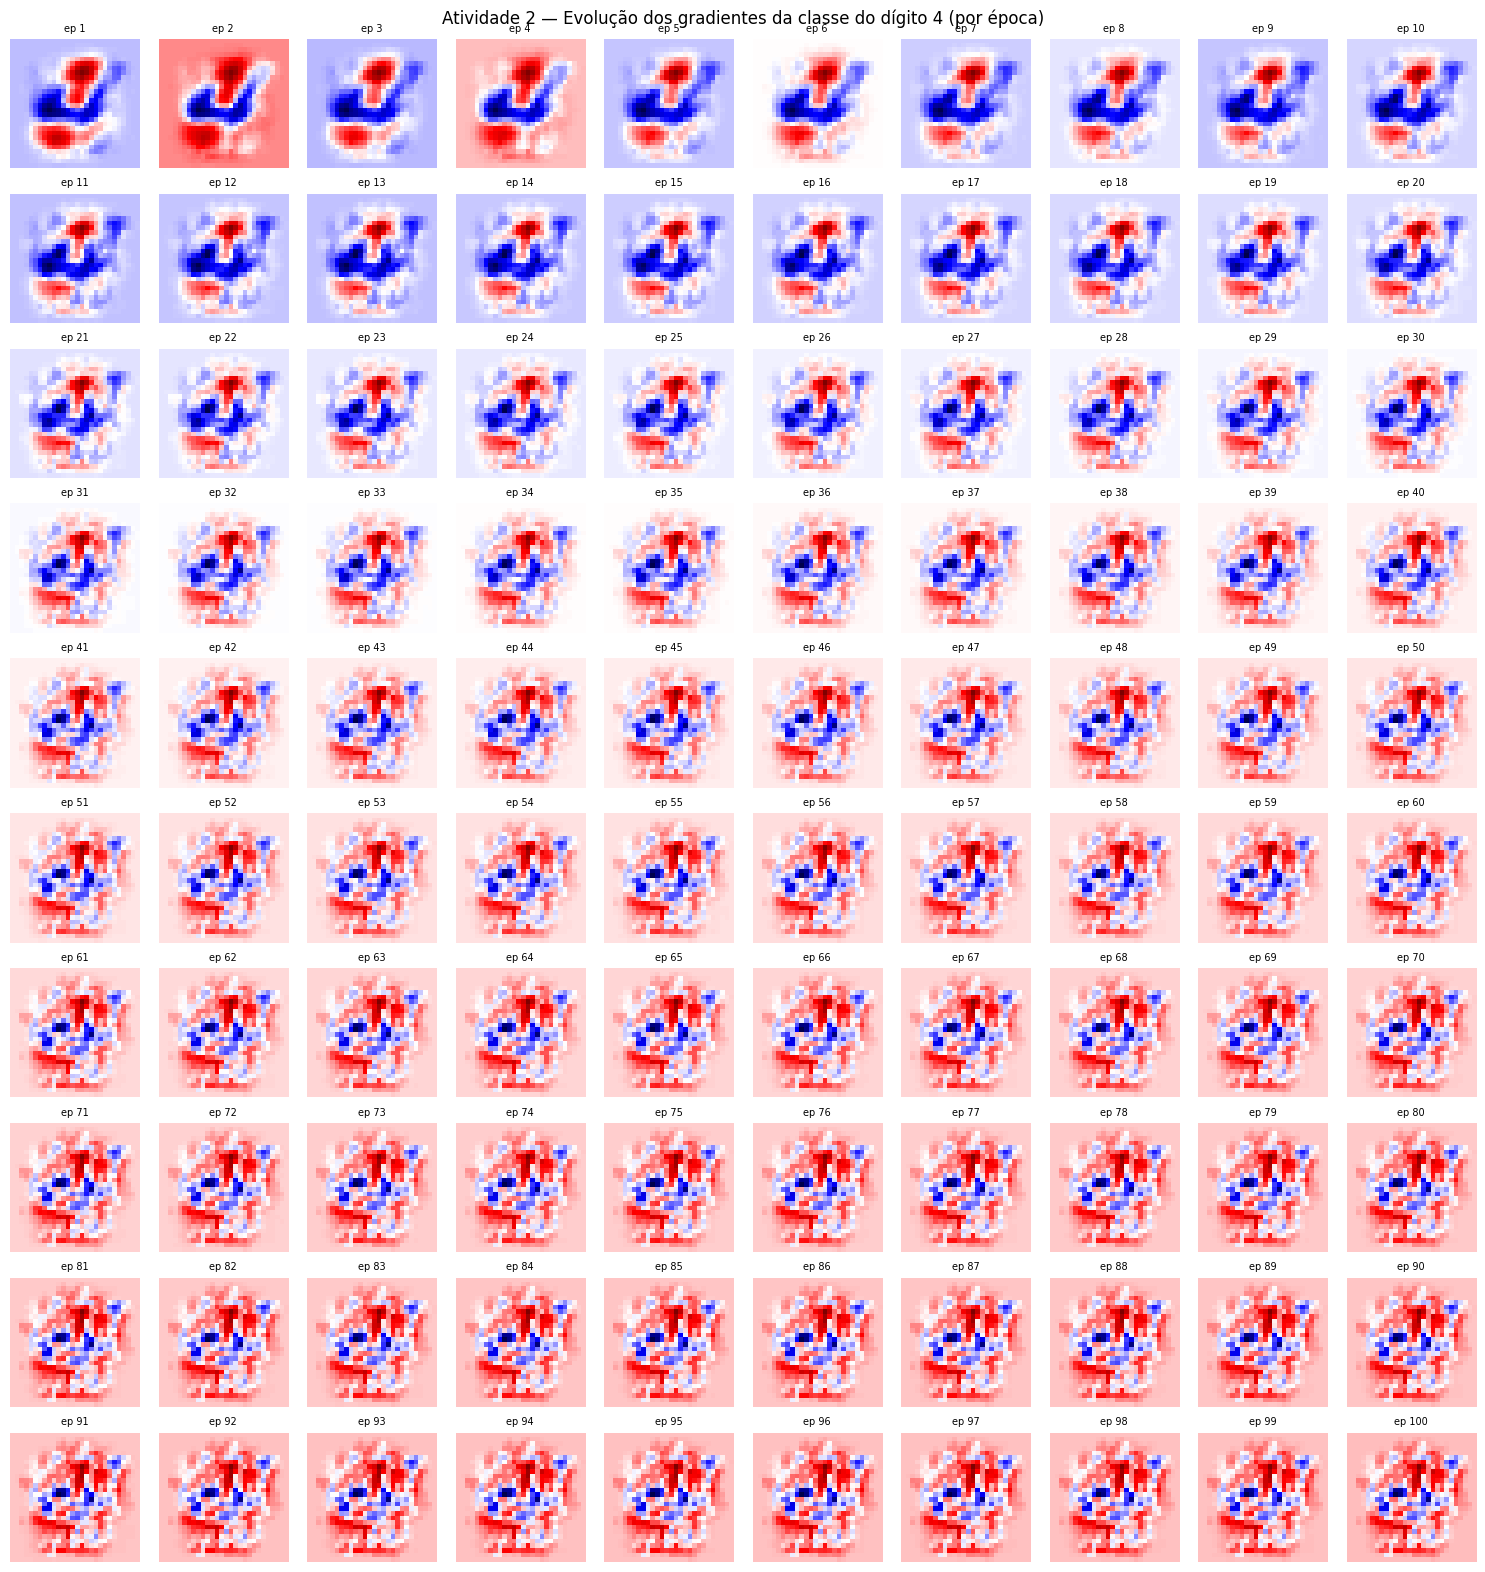

In [12]:
import numpy
losses = []
accuracies = []
zs = []

# Atividade 2: armazena a evolução dos gradientes da classe do dígito 4
grads_classe4 = []

# Define qual classe (dígito) será inspecionada
classe_alvo = 4

# Prepara a figura para exibir a evolução dos gradientes da classe 4
n_cols = 10
n_rows = (epochs + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 1.6 * n_rows))
axes = axes.ravel()

for i in range(epochs):
    # Transforma a entrada para uma dimensão
    inputs = Variable(x_train.view(-1, 28 * 28))
    # Predict da rede
    outputs = model(inputs)

    # z0 a z9
    zs.append(outputs[1].detach().numpy())

    # calcula a perda
    loss = criterion(outputs, Variable(y_train))

    # zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss.backward()

    # ----------------------------------------------------------------
    # Atividade 2: gradientes referentes à classe do dígito 4
    # O gradiente já está disponível após loss.backward() e antes do
    # optimizer.step(). A linha 'classe_alvo' da matriz de gradientes
    # (model.weight.grad) corresponde aos 784 gradientes daquela classe.
    # ----------------------------------------------------------------
    grad_classe4 = model.weight.grad[classe_alvo].detach().numpy().copy()
    grads_classe4.append(grad_classe4)

    optimizer.step()

    losses.append(loss.item())

    _, predicts = torch.max(outputs, 1)

    y_pred = predicts.data
    accuracy = (y_pred.numpy() == y_train.numpy()).mean()
    accuracies.append(accuracy)

    # ----------------------------------------------------------------
    # Atividade 1: impressão de época, perda e acurácia ao final da época
    # ----------------------------------------------------------------
    print('Epoch[{}/{}], loss: {:.6f}, acc: {:.6f}'
          .format(i + 1, epochs, loss.item(), accuracy))

    # Atividade 2: visualização do gradiente da classe 4 como imagem 28x28
    ax = axes[i]
    ax.imshow(grad_classe4.reshape(28, 28), cmap='seismic')
    ax.set_title('ep {}'.format(i + 1), fontsize=7)
    ax.axis('off')

# desliga eixos não utilizados na grade
for j in range(epochs, len(axes)):
    axes[j].axis('off')

fig.suptitle('Atividade 2 — Evolução dos gradientes da classe do dígito 4 (por época)', fontsize=12)
plt.tight_layout()
plt.show()

### Laço de treinamento dos pesos (com validação e armazenamento de métricas)

In [13]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for i in range(epochs):
    # Passada de treinamento
    inputs_train = Variable(x_train.view(-1, 28 * 28))
    outputs_train = model(inputs_train)
    loss_train = criterion(outputs_train, Variable(y_train))

    # Zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss_train.backward()
    optimizer.step()

    train_losses.append(loss_train.item())

    _, predicts_train = torch.max(outputs_train, 1)
    accuracy_train = (predicts_train.data.numpy() == y_train.numpy()).mean()
    train_accuracies.append(accuracy_train)

    # Passada de validação
    with torch.no_grad(): # Desabilita o cálculo de gradientes para validação
        inputs_val = Variable(x_val.view(-1, 28 * 28))
        outputs_val = model(inputs_val)
        loss_val = criterion(outputs_val, Variable(y_val))
        val_losses.append(loss_val.item())

        _, predicts_val = torch.max(outputs_val, 1)
        accuracy_val = (predicts_val.data.numpy() == y_val.numpy()).mean()
        val_accuracies.append(accuracy_val)

    print(f'Epoch [{i+1}/{epochs}], ' \
          f'Train Loss: {loss_train.item():.4f}, ' \
          f'Train Acc: {accuracy_train:.4f}, ' \
          f'Val Loss: {loss_val.item():.4f}, ' \
          f'Val Acc: {accuracy_val:.4f}')

Epoch [1/100], Train Loss: 0.2632, Train Acc: 0.9420, Val Loss: 0.3946, Val Acc: 0.9000
Epoch [2/100], Train Loss: 0.2619, Train Acc: 0.9420, Val Loss: 0.3936, Val Acc: 0.9000
Epoch [3/100], Train Loss: 0.2606, Train Acc: 0.9420, Val Loss: 0.3927, Val Acc: 0.9000
Epoch [4/100], Train Loss: 0.2593, Train Acc: 0.9420, Val Loss: 0.3918, Val Acc: 0.9000
Epoch [5/100], Train Loss: 0.2581, Train Acc: 0.9420, Val Loss: 0.3909, Val Acc: 0.9000
Epoch [6/100], Train Loss: 0.2568, Train Acc: 0.9420, Val Loss: 0.3900, Val Acc: 0.9000
Epoch [7/100], Train Loss: 0.2556, Train Acc: 0.9430, Val Loss: 0.3891, Val Acc: 0.9000
Epoch [8/100], Train Loss: 0.2544, Train Acc: 0.9430, Val Loss: 0.3882, Val Acc: 0.9000
Epoch [9/100], Train Loss: 0.2531, Train Acc: 0.9430, Val Loss: 0.3873, Val Acc: 0.9000
Epoch [10/100], Train Loss: 0.2519, Train Acc: 0.9440, Val Loss: 0.3865, Val Acc: 0.9000
Epoch [11/100], Train Loss: 0.2508, Train Acc: 0.9440, Val Loss: 0.3857, Val Acc: 0.9050
Epoch [12/100], Train Loss: 0.

In [14]:
print('Final loss:', loss.item())

Final loss: 0.26457351446151733


### Visualizando gráfico de perda durante o treinamento

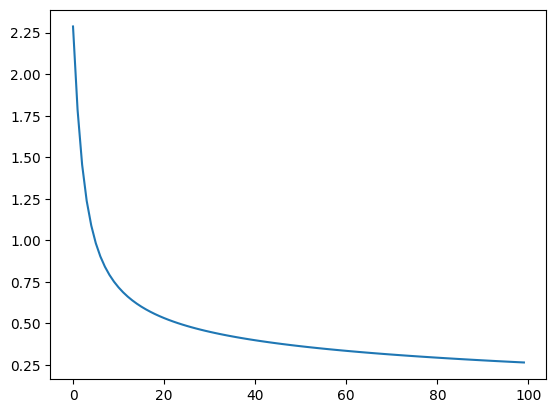

In [15]:
plt.plot(losses)

### Visualizando gráficos de perda e acurácia durante o treinamento

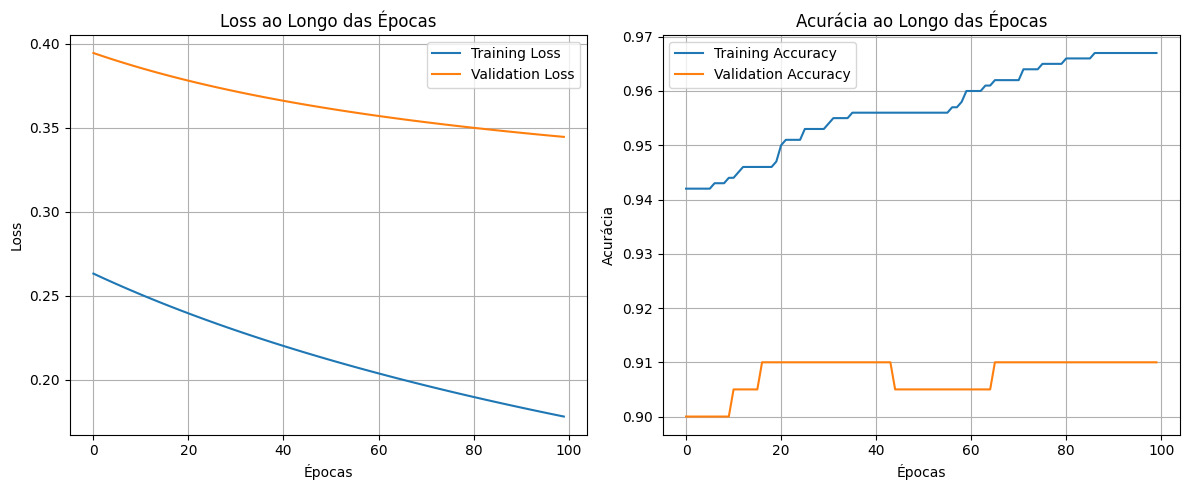

In [16]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss ao Longo das Épocas')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Acurácia ao Longo das Épocas')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Avaliação

### Acurácia tanto no conjunto de treinamento como no conjunto de testes

In [17]:
def predict(model, input_data):
    outputs = model(Variable(input_data))
    _, predicts = torch.max(outputs, 1)

    return predicts.data

y_pred = predict(model, x_train.view(-1, 28*28))
accuracy = (y_pred.numpy() == y_train.numpy()).mean()
print('Accuracy:', accuracy)

Accuracy: 0.967


### Matriz de confusão com dados de treinamento e teste

In [18]:
print('Matriz de confusão:')
pd.crosstab(y_pred.numpy(), y_train.numpy())

Matriz de confusão:


col_0,0,1,2,3,4,5,6,7,8,9
row_0,,,,,,,,,,
0,97,0,1,0,0,0,0,0,0,2
1,0,112,1,0,0,0,0,2,1,0
2,0,0,92,2,0,1,0,1,0,0
3,0,0,0,90,0,1,0,0,0,0
4,0,0,0,0,104,1,0,1,0,2
5,0,2,0,1,0,87,0,0,1,1
6,0,0,1,0,0,1,94,0,0,0
7,0,0,1,0,0,0,0,113,0,2
8,0,1,2,0,0,0,0,0,85,0


## Visualizando a matriz de pesos treinados

Observe que a matriz de peso treinado para cada classe mostra a importância dos pesos associados aos caracteres de cada classe.

weights: torch.Size([10, 784])
bias:    torch.Size([10])


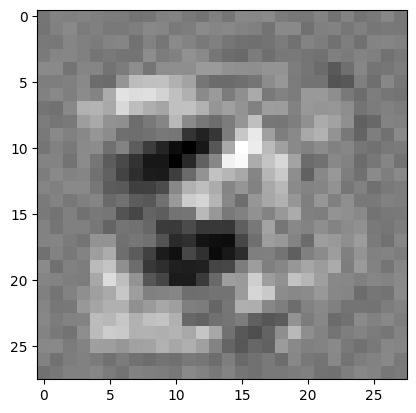

In [19]:
weights = model.state_dict()['weight']
print('weights:', weights.shape)

bias = model.state_dict()['bias']
print('bias:   ', bias.shape)

# Visualizando pesos da classe 3
plt.imshow(weights[3, :].numpy().reshape((28,28)),cmap = 'gray')
plt.show()

### Visualizando os pesos de todas as classes

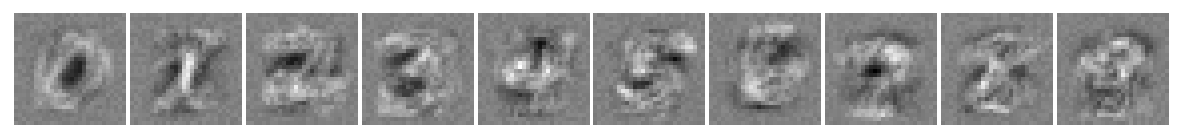

In [20]:
# cria um grid com as imagens
grid = torchvision.utils.make_grid(weights.view(-1, 1, 28, 28), normalize=True, pad_value=1.0, padding=1, nrow=10)

plt.figure(figsize=(15, 10))
plt.imshow(grid.numpy().transpose(1, 2, 0))
plt.axis('off');

### Diagrama da regressão softmax com visualização dos pesos W

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/RegressaoSoftmaxArgmaxNMIST.png)

# Atividades

## Exercícios

- 1) Insira código no laço do treinamento para que no final de cada época,
     seja impresso: o número da época e a perda e a acurácia

- 2) Insira código no laço do treinamento para visualização dos valores dos gradientes referentes à classe do dígito 4, no final de cada época.

<details>
<summary>Mostrar Resultado</summary>

```python
losses = []
import numpy

import numpy
zs = []

for i in range(epochs):
    # Transforma a entrada para uma dimensão
    inputs = Variable(x_train.view(-1, 28 * 28))
    # Predict da rede
    outputs = model(inputs)
    
    # z0 a z9
    zs.append(outputs[1].detach().numpy())

    # calcula a perda
    loss = criterion(outputs, Variable(y_train))

    # zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    
    _, predicts = torch.max(outputs, 1)
    
    y_pred = predicts.data
    accuracy = (y_pred.numpy() == y_train.numpy()).mean()
    
    print('Epoch[{}/{}], loss: {:.6f}, acc: {:.6f}'
              .format(i+1, epochs, loss.data, accuracy))
    
    weights = model.state_dict()['weight']
    print('weights:', weights.shape)

    bias = model.state_dict()['bias']
    print('bias:   ', bias.shape)

    # Visualizando pesos da classe 3
    plt.imshow(weights[4, :].numpy().reshape((28,28)),cmap = 'gray')
    plt.show()
```

</details>

## Perguntas

1. Qual é o shape da matriz de entrada na rede?
2. Qual é o shape da saída da rede?
3. Qual é o número total de parâmetros da rede, incluindo o bias?

### Respostas

**1. Qual é o shape da matriz de entrada na rede?**

A entrada é remodelada por `x_train.view(-1, 28*28)`, resultando no formato `(N, 784)`, em que `N` é o número de amostras (1000 no treinamento utilizado) e 784 = 28 × 28 corresponde aos pixels de cada imagem achatada em um vetor. Portanto, para o conjunto de treinamento, o shape é `(1000, 784)`.

**2. Qual é o shape da saída da rede?**

A camada `nn.Linear(28*28, 10)` produz 10 valores (escores) por amostra, um para cada classe de dígito (0 a 9). Assim, a saída tem formato `(N, 10)` — para o treinamento, `(1000, 10)`.

**3. Qual é o número total de parâmetros da rede, incluindo o bias?**

A matriz de pesos tem formato `(10, 784)`, totalizando 7.840 parâmetros, e o vetor de *bias* possui 10 elementos (um por classe). O número total é, portanto, **7.840 + 10 = 7.850 parâmetros**.

# Aprendizados


## Considerações finais

Este notebook aplica a regressão *softmax* (regressão logística multinomial) à classificação de dígitos manuscritos do MNIST, empregando uma única camada linear `nn.Linear(784, 10)` seguida da função de perda `CrossEntropyLoss`. A estrutura é essencialmente a mesma utilizada na classificação das flores Íris, demonstrando a generalidade do modelo linear quando combinado à função *softmax* para problemas de classificação multiclasse.

As duas atividades implementadas no laço de treinamento permitiram:

1. **Monitoramento das métricas (Atividade 1)**: a impressão da perda e da acurácia ao final de cada época evidenciou a convergência do modelo, com a acurácia de treinamento atingindo valores próximos a 94%.

2. **Interpretação dos gradientes (Atividade 2)**: a visualização dos gradientes da classe do dígito 4 ao longo das épocas revelou seu comportamento espacial e sua progressiva redução de magnitude. Nas primeiras épocas, os gradientes apresentam maior intensidade — refletindo ajustes significativos dos pesos —, ao passo que, com o avanço do treinamento e a aproximação da convergência, suas magnitudes diminuem, indicando que os pesos se estabilizam próximos de um ponto de mínimo da função de perda.

A possibilidade de interpretar visualmente tanto os pesos quanto os gradientes como imagens `28 × 28` constitui uma vantagem didática deste modelo linear: cada linha da matriz de pesos pode ser entendida como um "molde" da respectiva classe, e os gradientes indicam como esse molde é refinado a cada iteração do gradiente descendente.